In [1]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [3]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
X = iris.iloc[:, :4].values
y = iris.iloc[:, 4].values
print(y[:5])

['setosa' 'setosa' 'setosa' 'setosa' 'setosa']


In [4]:
#문자열에 label을 붙임
encoder = LabelEncoder()
y1 = encoder.fit_transform(y)
print(y1)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [5]:
#종속변수에 대한 원핫인코딩 처리
y2 = pd.get_dummies(y1).values
print(y2[:5])

[[ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]]


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y2, test_size=0.2, stratify=y, random_state=10)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
#조기학습종료 (validation loss 기준)
es = EarlyStopping(monitor='val_loss', patience=10)
#학습 과정에서 만들어진 최적의 파라미터 조합으로 모형을 저장
mc = ModelCheckpoint('iris_best.keras', save_best_only=True)
#학습이 잘 안될 때 학습률을 동적으로 조절하는 옵션
rlr = ReduceLROnPlateau(factor=0.1, patience=5)
#학습 과정의 주요 history를 csv로 저장
csvlogger = CSVLogger('mylog.csv')
hist = model.fit(X_train, y_train, validation_split=0.2, epochs=100, callbacks=[es, mc, rlr, csvlogger])

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3333 - loss: 1.1051 - val_accuracy: 0.2917 - val_loss: 1.1825 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4167 - loss: 1.0569 - val_accuracy: 0.1667 - val_loss: 1.1372 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3750 - loss: 1.0162 - val_accuracy: 0.2917 - val_loss: 1.0801 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6042 - loss: 0.9757 - val_accuracy: 0.4167 - val_loss: 1.0199 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3854 - loss: 0.9422 - val_accuracy: 0.4167 - val_loss: 0.9594 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5104 - loss: 0.9131 - val_accuracy: 0.7917 - val_loss: 0.9102 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6250 - loss: 0.8841 - val_accuracy: 

In [10]:
from tensorflow.keras.models import load_model
model = load_model('iris_best.keras')
model.evaluate(X_test, y_test, verbose=0)
# loss , accuracy

[0.10275085270404816, 0.9666666388511658]

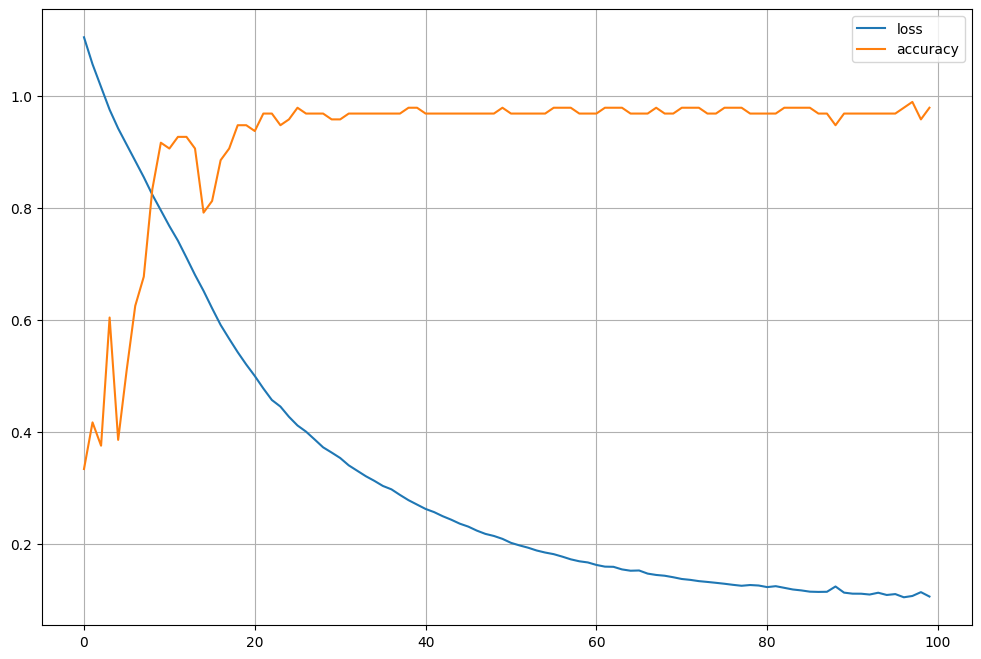

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.legend(['loss','accuracy'])
plt.grid()
plt.show()

In [12]:
#모델 평가
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print('정확도 = {:.2f}'.format(accuracy))

정확도 = 0.97


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix
pred = model.predict(X_test)
print(pred[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[1.1961204e-03 7.5594336e-01 2.4286054e-01]
 [9.9514872e-01 4.8414320e-03 9.7939383e-06]
 [7.9438166e-04 4.8695379e-01 5.1225179e-01]
 [2.9466886e-04 3.8739985e-01 6.1230546e-01]
 [1.3555051e-02 9.6551150e-01 2.0933488e-02]
 [5.5229877e-05 1.1336660e-01 8.8657814e-01]
 [9.9069387e-01 9.2772907e-03 2.8870892e-05]
 [1.3312690e-05 2.6501996e-02 9.7348469e-01]
 [8.5449474e-06 2.5454316e-02 9.7453713e-01]
 [9.9932754e-01 6.7194866e-04 5.0473483e-07]]


In [14]:
y_test_class = np.argmax(y_test, axis=1)
pred_class = np.argmax(pred, axis=1)
print(y_test_class[:10])
print(pred_class[:10])
print(confusion_matrix(y_test_class, pred_class))

[1 0 1 2 1 2 0 2 2 0]
[1 0 2 2 1 2 0 2 2 0]
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [15]:
model.save('c:/data/iris/iris.keras')

In [16]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#
# cm = confusion_matrix(y_test_class, pred_class)
#
# disp = ConfusionMatrixDisplay(
#     confusion_matrix=cm
# )
#
# disp.plot()

In [17]:
from keras.models import load_model   # (권장) keras 패키지
model = load_model('c:/data/iris/iris.keras')